# Red Neuronal Convolucional (CNN)

A diferencia del notebook 6 (MLP), donde "aplastábamos" la imagen (Flatten) al principio perdiendo la información espacial 2D, aquí procesaremos la imagen como una matriz, permitiendo que la red detecte patrones visuales (bordes, formas) sin importar dónde estén en la imagen.

## Importación de librerías

Primero, importamos PyTorch y las herramientas necesarias para manejar datos y visión por computador.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Configuración del dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Carga de Datos (FashionMNIST)

Usaremos los mismos datos que en el notebook 6, sin embargo, la forma en que la red los usará será diferente.

In [2]:
BATCH_SIZE = 64

# Transformaciones: A tensor y normalización
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalizamos para que los valores estén entre -1 y 1
    transforms.Normalize((0.5,), (0.5,)) 
])

# Descargar datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Entrenamiento: {len(train_dataset)} imágenes")
print(f"Test: {len(test_dataset)} imágenes")

Entrenamiento: 60000 imágenes
Test: 10000 imágenes


## Definición de la CNN (Convolutional Neural Network)

Definiremos:

1. Capa Convolucional (Conv2d): Extrae características (como los filtros del notebook anterior).

2. MaxPooling (MaxPool2d): Reduce el tamaño de la imagen, quedándose con la información más importante y reduciendo el cómputo.

3. Clasificador (Linear): Al final, "aplastamos" los mapas de características resultantes y usamos una capa densa clásica para decidir qué objeto es.

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # BLOQUE 1: Extracción de características
        # Entrada: 1 canal (gris), Salida: 32 filtros, Kernel: 3x3
        # Padding=1 mantiene el tamaño (28x28) después de la convolución
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduce a la mitad (14x14)
        
        # BLOQUE 2: Extracción de características más profundas
        # Entrada: 32 canales, Salida: 64 filtros
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Reutilizamos relu y pool (son funciones sin estado)
        
        # BLOQUE 3: Clasificador (Fully Connected)
        self.flatten = nn.Flatten()
        
        # Cálculo de dimensiones para la capa lineal:
        # La imagen original es 28x28.
        # Después de pool 1 -> 14x14
        # Después de pool 2 -> 7x7
        # Tenemos 64 canales de salida en conv2.
        # Total entradas: 64 * 7 * 7
        self.fc1 = nn.Linear(64 * 7 * 7, 600)
        self.fc2 = nn.Linear(600, 10) # 10 clases de salida
        
    def forward(self, x):
        # Bloque 1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Bloque 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Clasificación
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x) # Activación antes de la capa final
        logits = self.fc2(x)
        
        return logits

model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=600, bias=True)
  (fc2): Linear(in_features=600, out_features=10, bias=True)
)


## Función de Pérdida y Optimizador
Con fines de comparación directa, usaremos lo mismo que en el notebook 6.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Funciones de Entrenamiento y Prueba
Podemos reutilizar casi exactamente el mismo código del Notebook 6, ya que PyTorch abstrae la complejidad dentro del modelo.

In [5]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        # Predicción y pérdida
        pred = model(X)
        loss = loss_fn(pred, y)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

## Ejecución del Entrenamiento
Aunque el código es similar, la exactitud ("Accuracy") debería subir más rápido y llegar más alto que con la red multicapa simple (MLP).

In [6]:
EPOCHS = 5

for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, criterion, optimizer)
    test_loop(test_loader, model, criterion)

print("¡Entrenamiento con CNN finalizado!")

Epoch 1
-------------------------------
loss: 2.304344  [    0/60000]
loss: 0.280227  [ 6400/60000]
loss: 0.504452  [12800/60000]
loss: 0.445444  [19200/60000]
loss: 0.313126  [25600/60000]
loss: 0.392693  [32000/60000]
loss: 0.273645  [38400/60000]
loss: 0.304893  [44800/60000]
loss: 0.228934  [51200/60000]
loss: 0.125559  [57600/60000]
Test Error: 
 Accuracy: 89.0%, Avg loss: 0.308143 

Epoch 2
-------------------------------
loss: 0.212621  [    0/60000]
loss: 0.147811  [ 6400/60000]
loss: 0.164862  [12800/60000]
loss: 0.410578  [19200/60000]
loss: 0.246932  [25600/60000]
loss: 0.302730  [32000/60000]
loss: 0.155771  [38400/60000]
loss: 0.329174  [44800/60000]
loss: 0.237358  [51200/60000]
loss: 0.162800  [57600/60000]
Test Error: 
 Accuracy: 90.6%, Avg loss: 0.265378 

Epoch 3
-------------------------------
loss: 0.232186  [    0/60000]
loss: 0.132704  [ 6400/60000]
loss: 0.159780  [12800/60000]
loss: 0.219675  [19200/60000]
loss: 0.307553  [25600/60000]
loss: 0.148864  [32000/600

## Visualización y Predicción
Vamos a verificar visualmente un resultado.

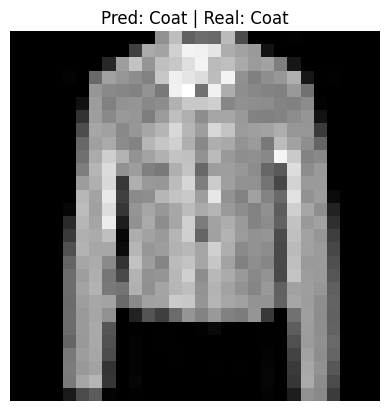

In [7]:
labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}

model.eval()
# Tomamos una imagen del test set
img, label = test_dataset[10] 
img_tensor = img.unsqueeze(0).to(device) # Añadir dimensión de batch

with torch.no_grad():
    pred = model(img_tensor)
    predicted_idx = pred.argmax(1).item()
    predicted_label = labels_map[predicted_idx]
    actual_label = labels_map[label]

plt.title(f"Pred: {predicted_label} | Real: {actual_label}")
plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

## Conclusiones

Diferencias clave a observar con respecto a una red multicapa:

- **Parámetros:** A pesar de ser más potente para imágenes, esta CNN puede tener menos parámetros que una MLP gigante, porque reutiliza los mismos filtros (pesos) en toda la imagen.

- **Rendimiento:** Tiene un mejor desempeño ya que detecta texturas y formas locales en lugar de solo mirar píxeles individuales.